Turning PIL/SciPy functions into native TensorFlow tensor operations to not bottleneck the training throughput

In [17]:
import tensorflow as tf
import matplotlib.pyplot as plt
import os

Gaussian Noise

In [ ]:
def tf_gaussian_noise(image, mean=0, stddev=0.05):
    noise = tf.random.normal(shape=tf.shape(image), mean=mean, stddev=stddev, dtype=tf.float32)
    tf_image = image + noise
    return tf.clip_by_value(tf_image, clip_value_min=0.0, clip_value_max=1.0)

Rayleigh Haze

In [ ]:
def tf_rayleigh(image, intensity=0.0):
    img = tf.image.adjust_contrast(image, contrast_factor=0.75)

    haze_color = tf.constant([150.0 / 255.0, 180.0 / 255.0, 220.0 / 255.0], dtype=tf.float32)

    blended = (1.0 - intensity) * img + intensity * haze_color
    return tf.clip_by_value(blended, 0.0, 1.0)

Jitter

In [20]:
def tf_jitter(image: tf.Tensor, max_brightness: float = 0.15, lower_contrast: float = 0.8, upper_contrast: float = 1.2) -> tf.Tensor:
    img = tf.image.random_brightness(image, max_delta=max_brightness)
    img = tf.image.random_contrast(img, lower=lower_contrast, upper=upper_contrast)
    return tf.clip_by_value(img, 0.0, 1.0)

Sun Glare

In [21]:
def tf_sun_glare(image: tf.Tensor, max_glare: float = 0.6) -> tf.Tensor:
    shape = tf.shape(image)
    h, w = shape[0], shape[1]
    
    solar_color = tf.constant([255.0 / 255.0, 245.0 / 255.0, 235.0 / 255.0], dtype=tf.float32)
    
    gradient = tf.linspace(max_glare, 0.0, w)
    mask = tf.tile(tf.expand_dims(gradient, 0), [h, 1])  # (H, W)
    mask = tf.expand_dims(mask, -1)                      # (H, W, 1)
    
    if tf.random.uniform([]) > 0.5:
        mask = tf.image.flip_left_right(mask)
        
    blended = (1.0 - mask) * image + mask * solar_color
    return tf.clip_by_value(blended, 0.0, 1.0)

Motion Blur

In [22]:
def tf_motion_blur(image: tf.Tensor, kernel_size: int = 5) -> tf.Tensor:
    k_center = kernel_size // 2
    
    kernel_1d = tf.zeros((kernel_size, kernel_size), dtype=tf.float32)
    indices = [[k_center, i] for i in range(kernel_size)]
    updates = tf.ones((kernel_size,), dtype=tf.float32) / float(kernel_size)
    kernel_2d = tf.tensor_scatter_nd_update(kernel_1d, indices, updates)
    
    kernel_4d = tf.expand_dims(tf.expand_dims(kernel_2d, -1), -1)
    kernel_4d = tf.tile(kernel_4d, [1, 1, 3, 1])
    
    img_4d = tf.expand_dims(image, 0)
    blurred = tf.nn.depthwise_conv2d(img_4d, kernel_4d, strides=[1, 1, 1, 1], padding="SAME")
    return tf.squeeze(blurred, axis=0)

Defocus Blur

In [23]:
def tf_defocus_blur(image: tf.Tensor, kernel_size: int = 5, sigma: float = 1.5) -> tf.Tensor:
    x = tf.range(-kernel_size // 2 + 1, kernel_size // 2 + 1, dtype=tf.float32)
    g = tf.exp(-(x ** 2) / (2.0 * sigma ** 2))
    g = g / tf.reduce_sum(g)
    
    g_2d = tf.tensordot(g, g, axes=0)
    
    kernel_4d = tf.expand_dims(tf.expand_dims(g_2d, -1), -1)
    kernel_4d = tf.tile(kernel_4d, [1, 1, 3, 1])
    
    img_4d = tf.expand_dims(image, 0)
    blurred = tf.nn.depthwise_conv2d(img_4d, kernel_4d, strides=[1, 1, 1, 1], padding="SAME")
    return tf.squeeze(blurred, axis=0)

Clouds

In [24]:
def tf_clouds(image: tf.Tensor, thickness: float = 0.5, coverage: float = 1.0) -> tf.Tensor:
    shape = tf.shape(image)
    h, w = shape[0], shape[1]
    
    low_res = tf.random.uniform((1, 4, 4, 1), minval=0.0, maxval=1.0, dtype=tf.float32)
    
    cloud_mask = tf.image.resize(low_res, [h, w], method="bicubic")
    cloud_mask = tf.squeeze(cloud_mask, axis=0)  # (H, W, 1)
    
    cloud_mask = tf.clip_by_value(cloud_mask * coverage * thickness, 0.0, 1.0)
    
    white_layer = tf.constant([1.0, 1.0, 1.0], dtype=tf.float32)
    blended = (1.0 - cloud_mask) * image + cloud_mask * white_layer
    return tf.clip_by_value(blended, 0.0, 1.0)

Test functions

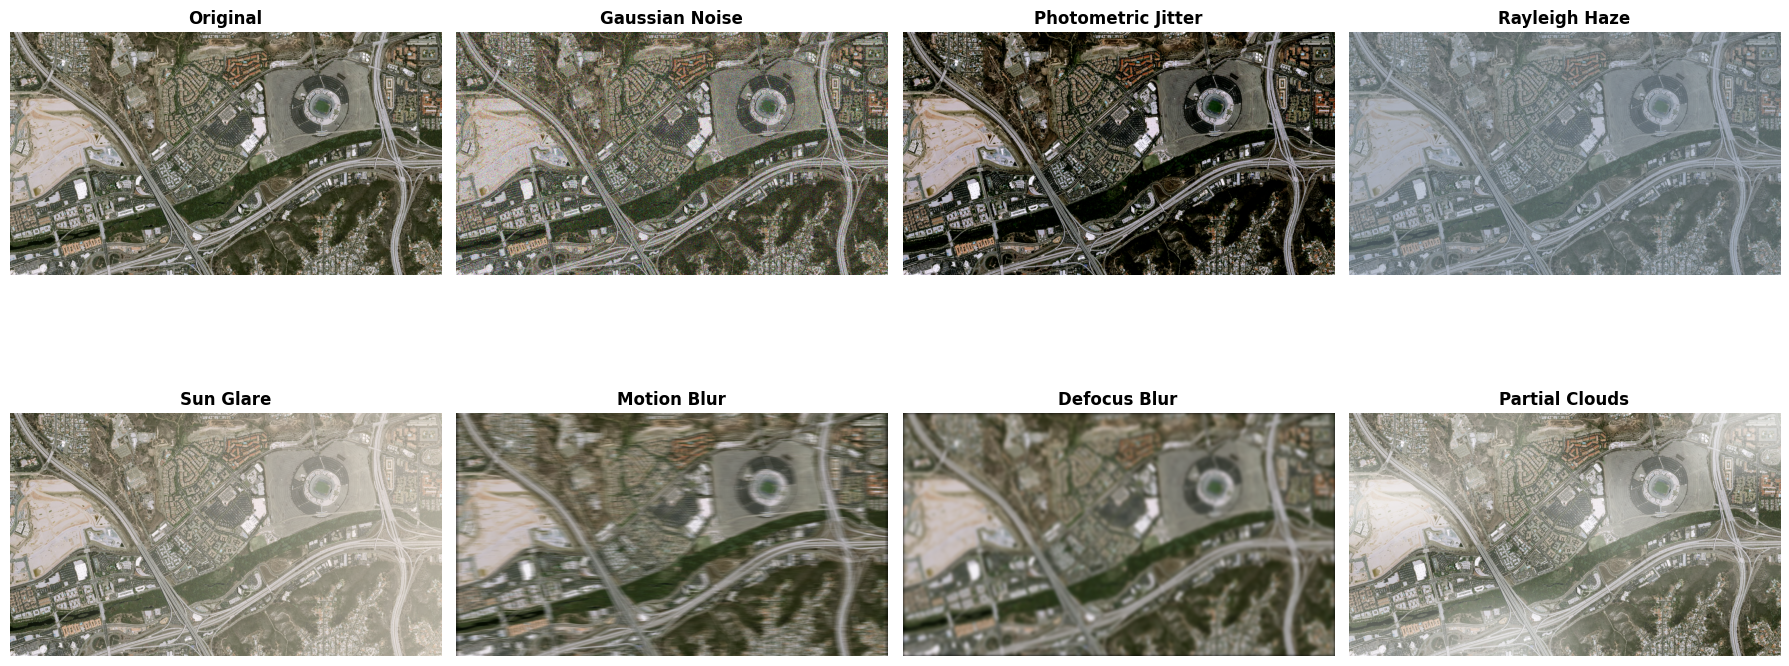

In [26]:
import os
import tensorflow as tf
import matplotlib.pyplot as plt

def load_and_distort_satellite_image(image_path = "src/data/satellite_image.jpg", plot = True):
    raw_file = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(raw_file, channels=3)
    
    image_float = tf.image.convert_image_dtype(image, dtype=tf.float32)

    results = {
        "Original": image_float,
        "Gaussian Noise": tf_gaussian_noise(image_float, stddev=0.20),
        "Photometric Jitter": tf_jitter(image_float, max_brightness=0.2, lower_contrast=0.6, upper_contrast=1.4),
        "Rayleigh Haze": tf_rayleigh(image_float, intensity=0.35),
        "Sun Glare": tf_sun_glare(image_float, max_glare=0.65),
        "Motion Blur": tf_motion_blur(image_float, kernel_size=31),
        "Defocus Blur": tf_defocus_blur(image_float, kernel_size=31, sigma=7.0),
        "Partial Clouds": tf_clouds(image_float, thickness=0.6, coverage=1.2)
    }

    if plot:
        fig, axes = plt.subplots(2, 4, figsize=(18, 9))
        axes = axes.flatten()

        for idx, (title, img_tensor) in enumerate(results.items()):
            axes[idx].imshow(img_tensor.numpy())
            axes[idx].set_title(title, fontsize=12, fontweight="bold")
            axes[idx].axis("off")

        plt.tight_layout()
        plt.show()

    return results

distorted_images = load_and_distort_satellite_image("satellite_image.jpg", plot=True)